# 6. Topic modeling with MALLET

What is podcasting *about*? Categories give a coarse answer — someone chose
"Society & Culture" from a dropdown once. Topic modeling gives a bottom-up
answer, derived from what people actually say.

This notebook fits an LDA model with **MALLET**, which remains the reference
implementation for Gibbs-sampled LDA and usually gives more coherent topics than
the common Python alternatives. It runs on the JVM, so we drive it through
`little-mallet-wrapper`.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))     # prefer the source tree
sys.path.insert(0, os.path.dirname(os.path.abspath("_viz.py")))

import sporc
if sporc.__version__ < "1.0":
    raise RuntimeError(
        f"This notebook needs sporc >= 1.0 but imported {sporc.__version__} from "
        f"{os.path.dirname(sporc.__file__)}.\n"
        "PyPI's latest release is 0.2.0, which has a different API, so "
        "`pip install sporc` gets you the wrong one. Install this checkout:\n"
        "    pip install -e /path/to/sporc"
    )

from _viz import apply_style, finish, PALETTE, INK, INK_SECONDARY, INK_MUTED
apply_style()
# Report the location relative to here, so the printed output does not embed
# whoever's home directory this happened to be built in.
print("sporc", sporc.__version__, "from",
      os.path.relpath(os.path.dirname(sporc.__file__)))


sporc 1.0.0 from ../../sporc


In [2]:
from sporc import SPORCDataset

# Built by scripts/make_subset.py; see examples/notebooks/README.md. Kept
# relative so nothing machine-specific leaks into the logged path.
SUBSET = "../../subsets/tutorial"
sporc = SPORCDataset(parquet_dir=SUBSET)
print(sporc)


INFO:sporc.dataset:Initializing Parquet backend from ../../subsets/tutorial


INFO:sporc.parquet_backend:Loading indexes from cache ../../subsets/tutorial/metadata/_index_cache.pkl


INFO:sporc.parquet_backend:ParquetBackend loaded from cache in 0.01s  (512 podcasts, 2,428 episodes)


SPORCDataset(parquet, 512 podcasts, 2428 episodes)


## 6.1 Pointing at MALLET

`little_mallet_wrapper` shells out to the `mallet` binary, so it needs MALLET on
disk and a working Java. Rather than hard-code a path, we resolve it from the
environment: set the **`MALLET_PATH`** environment variable to your MALLET
install's `bin/mallet`, or put `mallet` on your `PATH`. Java is found the same
way (`PATH`, or a `JAVA_HOME`).


In [3]:
import os, shutil, subprocess

# Resolve MALLET from the environment, never a fixed path: the MALLET_PATH env
# var if set, otherwise a `mallet` on PATH.
MALLET_PATH = os.environ.get("MALLET_PATH") or shutil.which("mallet")

if not MALLET_PATH or not os.path.exists(MALLET_PATH):
    raise SystemExit(
        "MALLET not found. Download it from https://mimno.github.io/Mallet/, "
        "then set the MALLET_PATH environment variable to its bin/mallet, or "
        "put `mallet` on your PATH."
    )

java = shutil.which("java")
if not java:
    raise SystemExit("Java not found on PATH -- MALLET runs on the JVM.")

# Print how each was resolved, not an absolute path, so this notebook's output
# stays free of machine-specific locations.
print("mallet : resolved from", "MALLET_PATH" if os.environ.get("MALLET_PATH") else "PATH")
print("java   :", subprocess.run([java, "-version"], capture_output=True,
                                  text=True).stderr.splitlines()[0])


mallet : resolved from MALLET_PATH


java   : openjdk version "11.0.27" 2025-04-15


## 6.2 Choosing the document unit

This is the modelling decision that matters most, and it is easy to make
thoughtlessly.

* **One document = one episode.** Few, long documents. LDA sees a whole
  wide-ranging conversation as one bag of words and returns mush.
* **One document = one turn.** Many, tiny documents. Most turns are a sentence;
  there is no co-occurrence to learn from.
* **One document = a window of turns.** A chunk of conversation that stays on
  roughly one thing. This is what `Episode.sliding_window()` is for.

We use windows. It is also a nice demonstration of the sliding-window API.


In [4]:
import little_mallet_wrapper as lmw
import pandas as pd

import random

# All 2,421 diarized episodes give ~4.1M tokens, which MALLET fits in ~20
# minutes -- too slow to sit and watch. 600 episodes still yields thousands of
# windows and readable topics. Raise it (or set None) for a real run.
N_EPISODES = 600

eps = [e for e in sporc.iterate_episodes() if e.has_turn_data]
print(f"diarized episodes: {len(eps):,}")

if N_EPISODES and len(eps) > N_EPISODES:
    eps.sort(key=lambda e: (e.podcast_title, e.title))
    eps = random.Random(0).sample(eps, N_EPISODES)
    print(f"sampled          : {len(eps):,}")

docs, meta = [], []
for e in eps:
    if e.turn_count < 12:
        continue
    for win in e.sliding_window(window_size=12, overlap=3):
        text = win.get_text()
        if len(text.split()) < 120:      # too short to carry a topic
            continue
        docs.append(text)
        # episode_id, not title: titles repeat (one podcast here has seven
        # episodes called "Daily Encouragement"), so grouping by title would
        # merge distinct episodes. Keep the title alongside for reading.
        meta.append({"episode_id": e.episode_id, "episode": e.title,
                     "podcast_id": e.podcast_id, "podcast": e.podcast_title,
                     "category": e.primary_category,
                     "date": e.episode_date,
                     "start": win.time_range[0]})

print(f"windows (documents): {len(docs):,}")
print(f"median words/doc   : {int(pd.Series([len(d.split()) for d in docs]).median())}"
      if docs else "")


INFO:sporc.parquet_backend:Loading episode DataFrame from feather cache


INFO:sporc.parquet_backend:Loading podcast DataFrame from feather cache


diarized episodes: 2,421
sampled          : 600


windows (documents): 7,611


median words/doc   : 256


In [5]:
# lmw's default processing lowercases, strips punctuation and short words.
# Podcast-specific stopwords matter: without them every topic is "like/know/yeah".
EXTRA_STOP = {
    "like", "know", "yeah", "just", "really", "think", "going", "right",
    "gonna", "okay", "kind", "sort", "actually", "want", "said", "say",
    "thing", "things", "people", "time", "lot", "way", "good", "little",
    "podcast", "episode", "welcome", "today", "talk", "talking", "guys",
    "come", "look", "make", "need", "let", "does", "did", "got", "get",
}

processed = [lmw.process_string(d, numbers="remove") for d in docs]
processed = [" ".join(w for w in d.split() if w not in EXTRA_STOP) for d in processed]
processed = [d for d in processed if len(d.split()) >= 60]

print(f"documents after cleaning: {len(processed):,}")
print(f"\nexample:\n  {processed[0][:220]}...")


documents after cleaning: 5,406

example:
  everyone phil matea feliciano school business topic timely listening business edge topic colleges reopen guest speaker david axelrod department economics professor feliciano school business axelrod thank axel rod taped s...


## 6.3 Fitting

`train_topic_model` writes MALLET's inputs to a directory, shells out, and reads
the results back. On a few thousand documents this takes a minute or two.


In [6]:
import tempfile, os

NUM_TOPICS = 15
outdir = tempfile.mkdtemp(prefix="sporc_lda_")
print("working dir:", outdir)

# Plain strings, not pathlib.Path: little_mallet_wrapper builds its shell
# command by string concatenation and raises TypeError on a PosixPath.
path_to_training_data       = os.path.join(outdir, "training.txt")
path_to_formatted_training  = os.path.join(outdir, "mallet.training")
path_to_model               = os.path.join(outdir, f"mallet.model.{NUM_TOPICS}")
path_to_topic_keys          = os.path.join(outdir, f"mallet.topic_keys.{NUM_TOPICS}")
path_to_topic_distributions = os.path.join(outdir, f"mallet.topic_distributions.{NUM_TOPICS}")
path_to_word_weights        = os.path.join(outdir, f"mallet.word_weights.{NUM_TOPICS}")
path_to_diagnostics         = os.path.join(outdir, f"mallet.diagnostics.{NUM_TOPICS}.xml")

lmw.import_data(MALLET_PATH, path_to_training_data, path_to_formatted_training,
                processed)
# train_topic_model's signature varies across little-mallet-wrapper releases:
# word_weights/diagnostics are required positionally here, and num_topics is
# positional too. Check inspect.signature(lmw.train_topic_model) if this raises.
lmw.train_topic_model(MALLET_PATH, path_to_formatted_training, path_to_model,
                      path_to_topic_keys, path_to_topic_distributions,
                      path_to_word_weights, path_to_diagnostics,
                      NUM_TOPICS)

topics = lmw.load_topic_keys(path_to_topic_keys)
dists = lmw.load_topic_distributions(path_to_topic_distributions)
print(f"\nfitted {len(topics)} topics over {len(dists)} documents")


working dir: /tmp/sporc_lda__wfw9l6e
Importing data...


Complete
Training topic model...


Mallet LDA: 15 topics, 4 topic bits, 1111 topic mask


Data loaded.


max tokens: 9910
total tokens: 975659


...

[beta: 0.03462] 
<980> LL/token: -8.53635


[beta: 0.03457] 
<990> LL/token: -8.53318



0	0.15182	one would back day well food cool three two put great big fun place probably last stuff love nice pretty 
1	0.0497	game street office elizabeth year one games team play last player guy two back first three see top big gear 
2	0.15491	great work school different kids help also young community life ways one years children business world working important education well 
3	0.0175	week one mean see lists list two next saw banned play would maybe could ban five definitely bands fire ship 
4	0.06673	black police one white even see also community part change lives racism mean well america land war within state american 
5	0.05631	team players game play sports back see season year league teams well playing baseball played games player coach would football 
6	0.08069	well covid also health government states world patients public countries country new care course crisis china state pandemic media may 
7	0.04885	god would one world book sense universe well particles could even life dif

[beta: 0.03471] 
<1000> LL/token: -8.53483

Total time: 5 minutes 8 seconds


Complete

fitted 15 topics over 5406 documents


In [7]:
for i, words in enumerate(topics):
    print(f"topic {i:2d}: {' '.join(words[:10])}")


topic  0: one would back day food well cool two three put
topic  1: game street office elizabeth year one games team guy last
topic  2: great work school different kids help life ways also one
topic  3: week one mean see lists list two banned next saw
topic  4: black police one white see even community change part racism
topic  5: team players game play sports see back season year league
topic  6: well covid also health government states world patients public countries
topic  7: god one would world sense universe particles book well could
topic  8: show thank com well music new also listening facebook email
topic  9: one movie see music would show stars well first movies
topic 10: book golf books news story new read well brian write
topic 11: body health eat food important eating brain one sleep help
topic 12: one would something mean well even always much see back
topic 13: man didn one guy went mean dad would well never
topic 14: business money one company well sales real property pa

## 6.4 Naming the topics

Top words are a prompt, not a label. Read them, read a couple of the documents
that load highest, and name the topic yourself. Automatic labels are how topic
models get over-interpreted.


In [8]:
import numpy as np

D = np.array(dists)
print("Highest-loading document for a few topics:\n")
for t in range(min(4, NUM_TOPICS)):
    j = int(D[:, t].argmax())
    print(f"topic {t} ({' '.join(topics[t][:6])})")
    print(f"   {meta[j]['podcast'][:44]!r} — {meta[j]['category']}")
    print(f"   {processed[j][:170]}...\n")


Highest-loading document for a few topics:

topic 0 (one would back day food well)
   'New Books in Critical Theory' — science
   two years since back haven seen grandparents two years probably longest haven supposed year try fall baby try spring pandemic happened obsessively buying taiwanese statio...

topic 1 (game street office elizabeth year one)
   'The Billy Madison Show Podcast' — comedy
   elizabeth street office elizabeth street office elizabeth street office elizabeth street office elizabeth street office elizabeth street office elizabeth street office el...

topic 2 (great work school different kids help)
   'Calling to the Good' — society
   great great great great great great great great great great great great great great great great great great great great great great great great great great great great gr...

topic 3 (week one mean see lists list)
   'Woke and Baked' — leisure
   sloan reaper four thai fighters two thai interceptors won believe top head sounds familiar 

## 6.5 Topic prevalence by category

Do the bottom-up topics line up with the top-down categories? Where they diverge
is usually the interesting part.


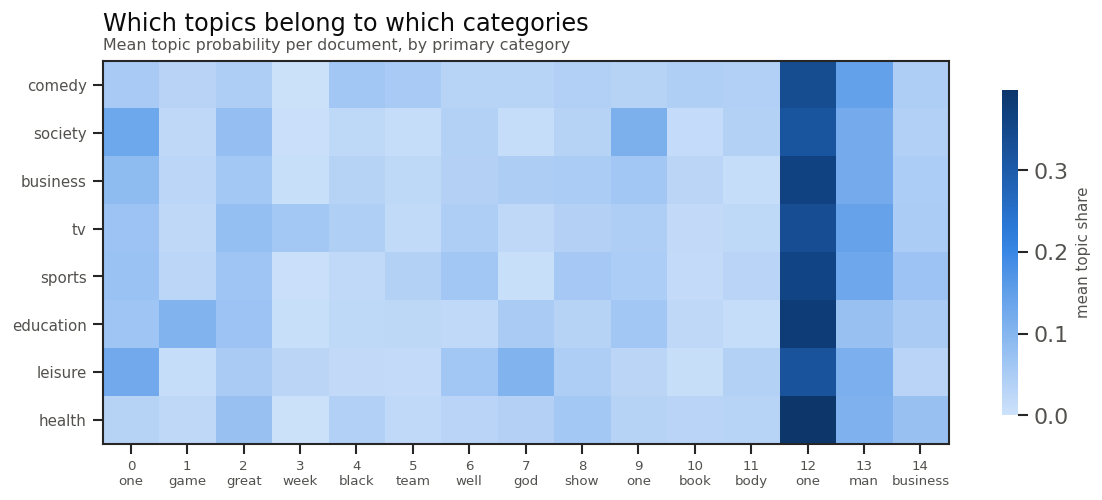

In [9]:
import matplotlib.pyplot as plt
from _viz import sequential_cmap

m = pd.DataFrame(meta[:len(D)])
m = m.assign(**{f"t{i}": D[:, i] for i in range(NUM_TOPICS)})

top_cats = m.category.value_counts().head(8).index.tolist()
mat = (m[m.category.isin(top_cats)]
         .groupby("category")[[f"t{i}" for i in range(NUM_TOPICS)]].mean()
         .loc[top_cats])

fig, ax = plt.subplots(figsize=(10, 4.4))
im = ax.imshow(mat.values, aspect="auto", cmap=sequential_cmap(), vmin=0)
ax.set_xticks(range(NUM_TOPICS))
ax.set_xticklabels([f"{i}\n{topics[i][0][:9]}" for i in range(NUM_TOPICS)],
                   fontsize=8)
ax.set_yticks(range(len(mat)))
ax.set_yticklabels(mat.index, fontsize=9)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, shrink=0.85)
cb.set_label("mean topic share", fontsize=9, color=INK_SECONDARY)
cb.outline.set_visible(False)
finish(ax, title="Which topics belong to which categories",
       subtitle="Mean topic probability per document, by primary category")
plt.show()


In [10]:
# The most category-distinctive topic: highest share relative to its own mean.
rel = mat / mat.mean(axis=0)
for cat in mat.index:
    t = int(rel.loc[cat].values.argmax())
    print(f"  {cat:26s} -> topic {t:2d}  ({' '.join(topics[t][:6])})")


  comedy                     -> topic  5  (team players game play sports see)
  society                    -> topic  9  (one movie see music would show)
  business                   -> topic 10  (book golf books news story new)
  tv                         -> topic  3  (week one mean see lists list)
  sports                     -> topic  5  (team players game play sports see)
  education                  -> topic  1  (game street office elizabeth year one)
  leisure                    -> topic  7  (god one would world sense universe)
  health                     -> topic 14  (business money one company well sales)


## 6.6 Caveats

* **k is a choice, not a finding.** 15 topics because we said 15. Fit several
  values and look at them; there is no "correct" k, and coherence metrics only
  narrow the field.
* **Stopwords shape the result.** The `EXTRA_STOP` list above is doing real work:
  without it, conversational filler dominates every topic. That list is a
  researcher decision and belongs in your write-up.
* **Windows overlap.** `overlap=3` means adjacent documents share turns, so
  documents are not independent. Fine for description, wrong for anything
  inferential.
* **Ads.** Podcast transcripts are full of read advertising, which forms tight,
  high-coherence topics that are about the ad market rather than the show.
* **Two months, 33% coverage.** As everywhere in SPoRC.
